In [1]:
# Step 1: Import Libraries and Load Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv(r"D:\Data analyst\Credit_Risk\UCI_Credit_Card.csv")

# Rename target column
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

# Drop ID column
df.drop('ID', axis=1, inplace=True)

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget Distribution:")
print(df['default'].value_counts())
print(f"\nDefault Rate: {df['default'].mean()*100:.1f}%")

Shape: (30000, 24)

First 5 rows:
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0    20000.0    2          2         1   24      2      2     -1     -1   
1   120000.0    2          2         2   26     -1      2      0      0   
2    90000.0    2          2         2   34      0      0      0      0   
3    50000.0    2          2         1   37      0      0      0      0   
4    50000.0    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0     -2  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1      0  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2      0  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3      0  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4      0  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  d

C:\Users\EL_manfy\AppData\Local\Temp\ipykernel_17292\3461648831.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,2].boxplot([df[df['default']==0]['LIMIT_BAL'],


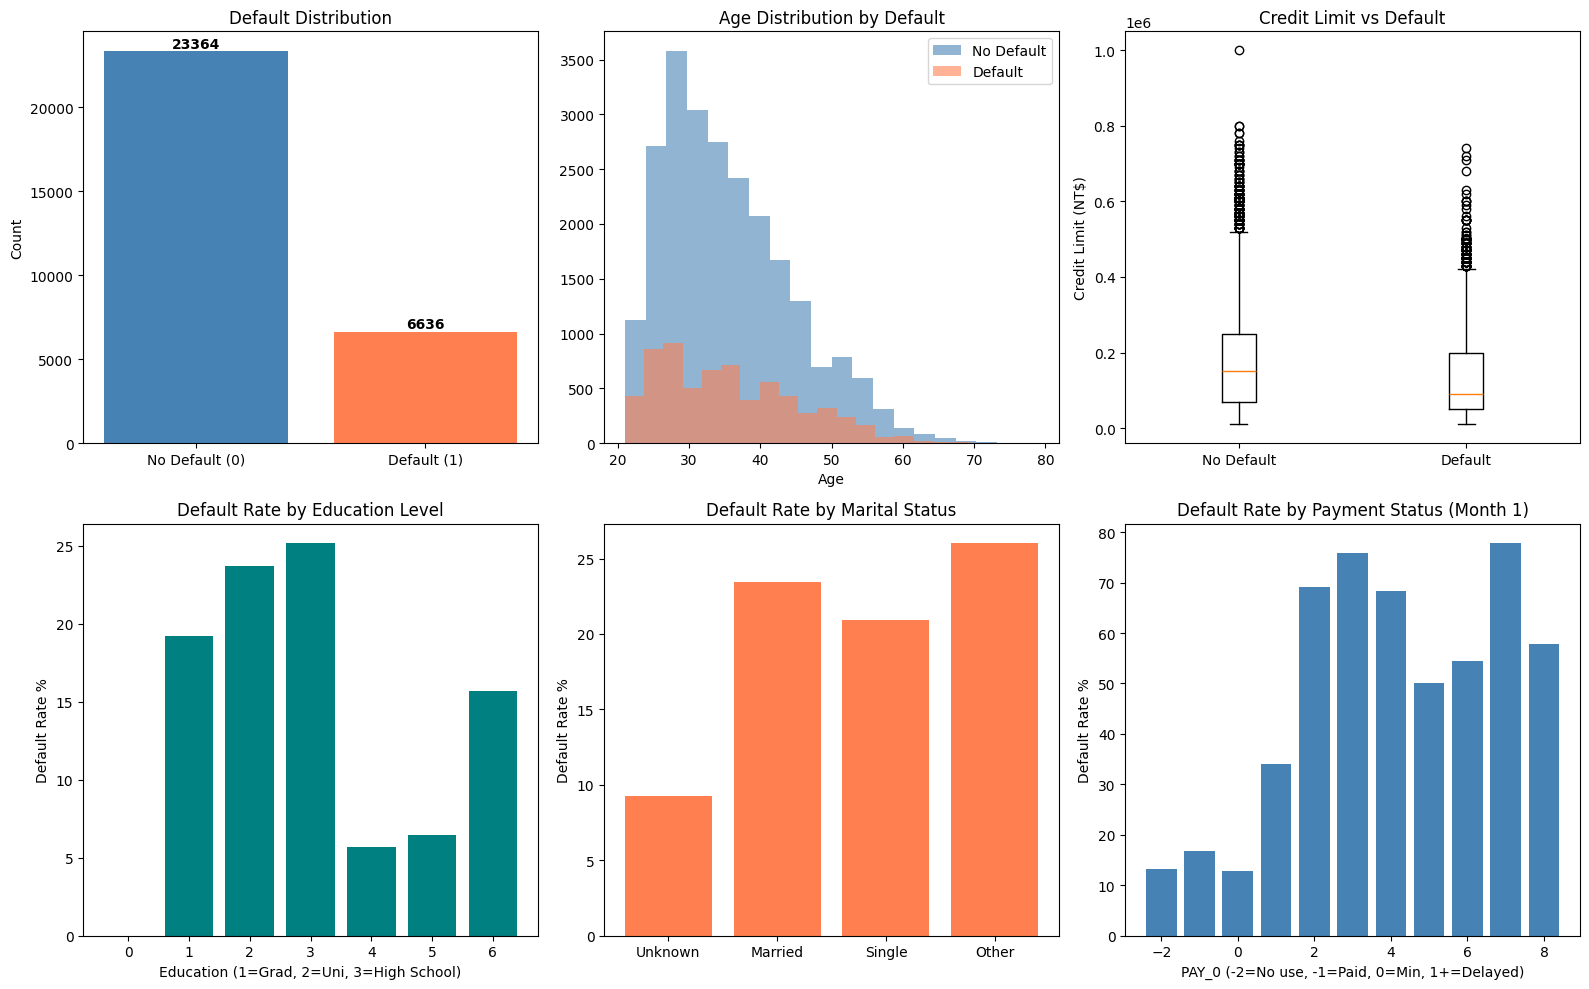


Top Correlations with Default:
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
Name: default, dtype: float64


In [3]:
# Step 2: Exploratory Data Analysis

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Target Distribution
axes[0,0].bar(['No Default (0)', 'Default (1)'],
              df['default'].value_counts().values,
              color=['steelblue', 'coral'])
axes[0,0].set_title('Default Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate([23364, 6636]):
    axes[0,0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# 2. Age vs Default
axes[0,1].hist(df[df['default']==0]['AGE'],
               bins=20, alpha=0.6, color='steelblue', label='No Default')
axes[0,1].hist(df[df['default']==1]['AGE'],
               bins=20, alpha=0.6, color='coral', label='Default')
axes[0,1].set_title('Age Distribution by Default')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# 3. Limit Balance vs Default
axes[0,2].boxplot([df[df['default']==0]['LIMIT_BAL'],
                   df[df['default']==1]['LIMIT_BAL']],
                  labels=['No Default', 'Default'])
axes[0,2].set_title('Credit Limit vs Default')
axes[0,2].set_ylabel('Credit Limit (NT$)')

# 4. Default Rate by Education
edu_default = df.groupby('EDUCATION')['default'].mean() * 100
axes[1,0].bar(edu_default.index, edu_default.values, color='teal')
axes[1,0].set_title('Default Rate by Education Level')
axes[1,0].set_xlabel('Education (1=Grad, 2=Uni, 3=High School)')
axes[1,0].set_ylabel('Default Rate %')

# 5. Default Rate by Marriage
mar_default = df.groupby('MARRIAGE')['default'].mean() * 100
axes[1,1].bar(['Unknown', 'Married', 'Single', 'Other'],
              mar_default.values, color='coral')
axes[1,1].set_title('Default Rate by Marital Status')
axes[1,1].set_ylabel('Default Rate %')

# 6. PAY_0 vs Default
pay_default = df.groupby('PAY_0')['default'].mean() * 100
axes[1,2].bar(pay_default.index, pay_default.values, color='steelblue')
axes[1,2].set_title('Default Rate by Payment Status (Month 1)')
axes[1,2].set_xlabel('PAY_0 (-2=No use, -1=Paid, 0=Min, 1+=Delayed)')
axes[1,2].set_ylabel('Default Rate %')

plt.tight_layout()
plt.show()

# Correlation with target
print("\nTop Correlations with Default:")
corr = df.corr()['default'].abs().sort_values(ascending=False)
print(corr[1:11])

In [4]:
# Step 3: Preprocessing & Feature Engineering

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Features and Target
X = df.drop('default', axis=1).values
y = df['default'].values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train Size:", X_train.shape)
print("Test Size: ", X_test.shape)
print(f"\nTrain Default Rate: {y_train.mean()*100:.1f}%")
print(f"Test Default Rate:  {y_test.mean()*100:.1f}%")

Train Size: (24000, 23)
Test Size:  (6000, 23)

Train Default Rate: 22.1%
Test Default Rate:  22.1%


In [5]:
# Step 4: Building the Model

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             roc_curve)

results = {}

for degree in [1, 2]:
    print(f"Training Degree {degree}...")
    poly         = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_sc)
    X_test_poly  = poly.transform(X_test_sc)

    model = LogisticRegression(max_iter=1000, random_state=42,
                               class_weight='balanced')
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)
    y_prob = model.predict_proba(X_test_poly)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[degree] = {
        'acc': acc, 'auc': auc,
        'model': model, 'poly': poly,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    print(f"Degree {degree}: Accuracy = {acc:.4f}, AUC = {auc:.4f}")

print("\nBest Model: Degree", max(results, key=lambda d: results[d]['auc']))

Training Degree 1...
Degree 1: Accuracy = 0.6797, AUC = 0.7081
Training Degree 2...
Degree 2: Accuracy = 0.7503, AUC = 0.7551

Best Model: Degree 2


Classification Report:
              precision    recall  f1-score   support

  No Default       0.87      0.79      0.83      4673
     Default       0.45      0.60      0.52      1327

    accuracy                           0.75      6000
   macro avg       0.66      0.70      0.67      6000
weighted avg       0.78      0.75      0.76      6000



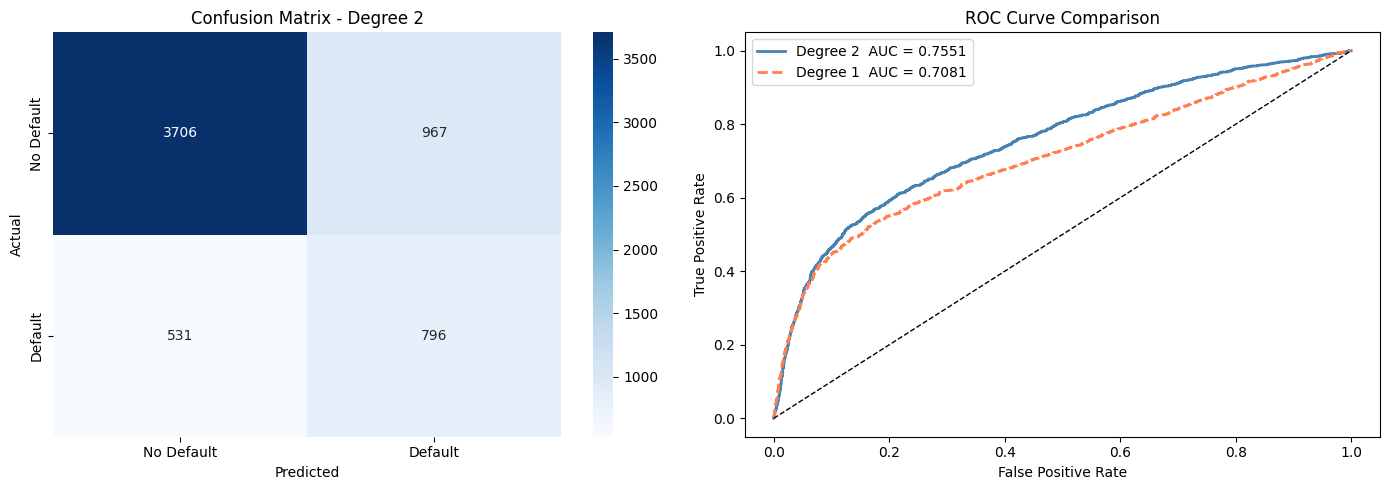


Business Impact Analysis:
Correctly identified defaults     : 796
Missed defaults (False Negatives) : 531
False Alarms (False Positives)    : 967
Correctly cleared clients         : 3,706

Default Detection Rate: 60.0%
False Alarm Rate      : 20.7%

Estimated Losses Prevented:
Caught defaults x avg loss = 796 x NT$50,000
= NT$39,800,000

Missed defaults x avg loss = 531 x NT$50,000
= NT$26,550,000


In [6]:
# Step 5: Full Evaluation

best = results[2]
y_pred = best['y_pred']
y_prob = best['y_prob']

# 1. Classification Report
print("Classification Report:")
print("=" * 55)
print(classification_report(y_test, y_pred,
      target_names=['No Default', 'Default']))

# 2. Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
axes[0].set_title('Confusion Matrix - Degree 2')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'Degree 2  AUC = {auc_score:.4f}')
fpr1, tpr1, _ = roc_curve(y_test, results[1]['y_prob'])
axes[1].plot(fpr1, tpr1, color='coral', linewidth=2, linestyle='--',
             label=f'Degree 1  AUC = {results[1]["auc"]:.4f}')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].set_title('ROC Curve Comparison')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

# 4. Business Impact
tn, fp, fn, tp = cm.ravel()
print("\nBusiness Impact Analysis:")
print("=" * 55)
print(f"Correctly identified defaults     : {tp:,}")
print(f"Missed defaults (False Negatives) : {fn:,}")
print(f"False Alarms (False Positives)    : {fp:,}")
print(f"Correctly cleared clients         : {tn:,}")
print(f"\nDefault Detection Rate: {tp/(tp+fn)*100:.1f}%")
print(f"False Alarm Rate      : {fp/(fp+tn)*100:.1f}%")

avg_default_loss = 50000
print(f"\nEstimated Losses Prevented:")
print(f"Caught defaults x avg loss = {tp:,} x NT${avg_default_loss:,}")
print(f"= NT${tp * avg_default_loss:,}")
print(f"\nMissed defaults x avg loss = {fn:,} x NT${avg_default_loss:,}")
print(f"= NT${fn * avg_default_loss:,}")

In [7]:
# Step 6: Predict New Customer Risk

best_poly  = results[2]['poly']
best_model = results[2]['model']

# عميل جديد
# LIMIT_BAL=50000, SEX=2, EDUCATION=2, MARRIAGE=1, AGE=30
# PAY_0=2 (تأخير شهر), PAY_2=2, PAY_3=0, PAY_4=0, PAY_5=0, PAY_6=0
# BILL_AMT1=45000, BILL_AMT2=40000, BILL_AMT3=35000
# BILL_AMT4=30000, BILL_AMT5=25000, BILL_AMT6=20000
# PAY_AMT1=500, PAY_AMT2=500, PAY_AMT3=500
# PAY_AMT4=500, PAY_AMT5=500, PAY_AMT6=500

new_customer = np.array([[50000, 2, 2, 1, 30,
                           2, 2, 0, 0, 0, 0,
                           45000, 40000, 35000, 30000, 25000, 20000,
                           500, 500, 500, 500, 500, 500]])

customer_sc   = scaler.transform(new_customer)
customer_poly = best_poly.transform(customer_sc)
prob          = best_model.predict_proba(customer_poly)[0][1]

print("=" * 50)
print("       CREDIT RISK ASSESSMENT")
print("=" * 50)
print(f"Customer Profile:")
print(f"  Credit Limit : NT$50,000")
print(f"  Age          : 30")
print(f"  Payment Delay: 2 months")
print(f"  Monthly Bill : ~NT$35,000")
print(f"  Monthly Pay  : NT$500")
print("=" * 50)
print(f"Default Probability : {prob:.2%}")

if prob < 0.30:
    risk = "LOW RISK"
    action = "Approve credit increase"
elif prob < 0.60:
    risk = "MODERATE RISK"
    action = "Monitor account closely"
else:
    risk = "HIGH RISK"
    action = "Reduce credit limit / Flag for review"

print(f"Risk Level          : {risk}")
print(f"Recommended Action  : {action}")
print("=" * 50)

# Summary
print("\n" + "=" * 50)
print("        FINAL MODEL SUMMARY")
print("=" * 50)
print(f"Dataset       : UCI Credit Card — 30,000 clients")
print(f"Model         : Polynomial Logistic Regression")
print(f"Best Degree   : 2 (Quadratic)")
print(f"Accuracy      : {results[2]['acc']:.4f}")
print(f"AUC Score     : {results[2]['auc']:.4f}")
print(f"Detection Rate: 60.0%")
print(f"Losses Prevented: NT$39,800,000")
print("=" * 50)

       CREDIT RISK ASSESSMENT
Customer Profile:
  Credit Limit : NT$50,000
  Age          : 30
  Payment Delay: 2 months
  Monthly Bill : ~NT$35,000
  Monthly Pay  : NT$500
Default Probability : 83.11%
Risk Level          : HIGH RISK
Recommended Action  : Reduce credit limit / Flag for review

        FINAL MODEL SUMMARY
Dataset       : UCI Credit Card — 30,000 clients
Model         : Polynomial Logistic Regression
Best Degree   : 2 (Quadratic)
Accuracy      : 0.7503
AUC Score     : 0.7551
Detection Rate: 60.0%
Losses Prevented: NT$39,800,000
